[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\krish\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   Unnamed: 0 label                                               text  \
0         605   ham  Subject: enron methanol ; meter # : 988291\r\n...   
1        2349   ham  Subject: hpl nom for january 9 , 2001\r\n( see...   
2        3624   ham  Subject: neon retreat\r\nho ho ho , we ' re ar...   
3        4685  spam  Subject: photoshop , windows , office . cheap ...   
4        2030   ham  Subject: re : indian springs\r\nthis deal is t...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  
(5171, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5171 non-null   int64 
 1   label       5171 non-null   object
 2   text        5171 non-null   object
 3   label_num   5171 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB
None

Missing Values:
Unnamed: 0    0
label         0
tex

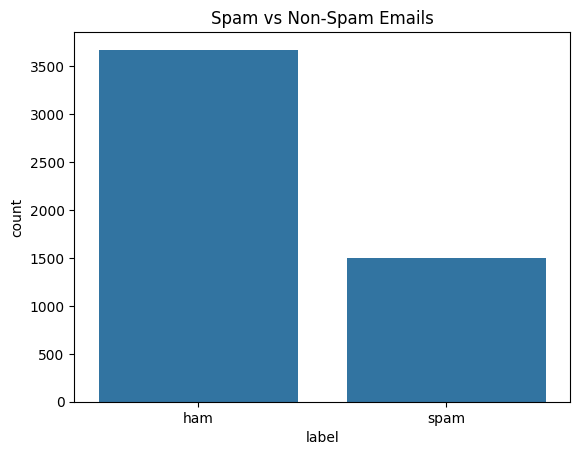

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7603 - loss: 0.5326 - val_accuracy: 0.8901 - val_loss: 0.2910
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9111 - loss: 0.2355 - val_accuracy: 0.9420 - val_loss: 0.1468
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9483 - loss: 0.1389 - val_accuracy: 0.9565 - val_loss: 0.1150
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9643 - loss: 0.0936 - val_accuracy: 0.9348 - val_loss: 0.1197
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9737 - loss: 0.0712 - val_accuracy: 0.9517 - val_loss: 0.1105
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9695 - loss: 0.0775 - val_accuracy: 0.9783 - val_loss: 0.0635
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9852 - loss: 0.0424 - val_accuracy: 0.9408 - val_loss: 0.1508
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9743 - loss: 0.0632 - val_accuracy: 0.

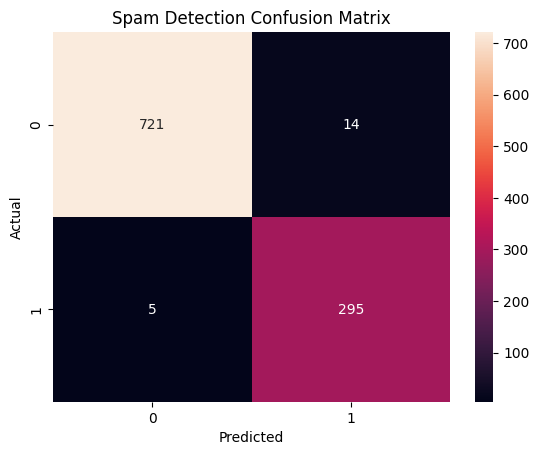

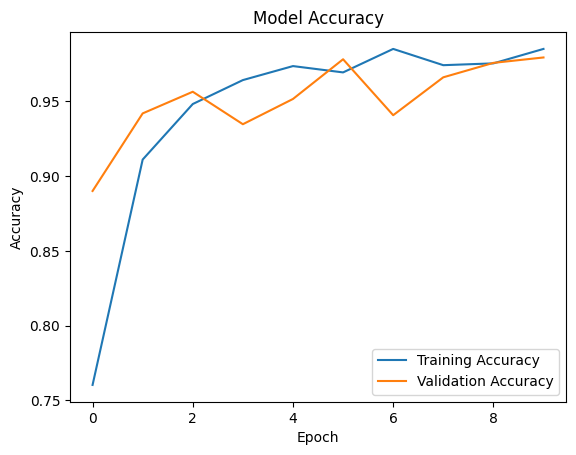

SPAM EMAIL DETECTION COMPLETED


In [3]:
# ============================================
# SPAM EMAIL DETECTION
# ============================================

# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout


# Download stopwords
nltk.download("stopwords")


# ============================================
# 2. Load Dataset
# ============================================

data = pd.read_csv("spam_ham_dataset.csv")

print(data.head())
print(data.shape)
print(data.info())


# ============================================
# 3. Check Missing Values
# ============================================

print("\nMissing Values:")
print(data.isnull().sum())


# ============================================
# 4. Check Class Distribution
# ============================================

print("\nClass Distribution:")
print(data["label"].value_counts())

sns.countplot(x="label", data=data)
plt.title("Spam vs Non-Spam Emails")
plt.show()


# ============================================
# 5. Text Cleaning
# ============================================

stop_words = set(stopwords.words("english"))


def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)


data["clean_text"] = data["text"].apply(clean_text)


# ============================================
# 6. Features and Target
# ============================================

X = data["clean_text"]
y = data["label_num"]


# ============================================
# 7. Train Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ============================================
# 8. Tokenization
# ============================================

tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)

X_test_sequences = tokenizer.texts_to_sequences(X_test)


# ============================================
# 9. Padding
# ============================================

max_length = 200

X_train_pad = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding="post"
)

X_test_pad = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding="post"
)


# ============================================
# 10. Deep Learning Model
# ============================================

model = Sequential([

    Embedding(
        input_dim=10000,
        output_dim=32
    ),

    GlobalAveragePooling1D(),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )

])


# ============================================
# 11. Compile Model
# ============================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ============================================
# 12. Train Model
# ============================================

history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


# ============================================
# 13. Evaluate
# ============================================

loss, accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("\nTest Accuracy:", accuracy)


# ============================================
# 14. Predictions
# ============================================

predictions = model.predict(X_test_pad)

predictions = (
    predictions > 0.5
).astype(int)


print(
    classification_report(
        y_test,
        predictions
    )
)


# ============================================
# 15. Confusion Matrix
# ============================================

cm = confusion_matrix(
    y_test,
    predictions
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Spam Detection Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ============================================
# 16. Training Graph
# ============================================

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()


print("SPAM EMAIL DETECTION COMPLETED")